**Aufgabe 5.a**

In dieser Aufgabe nutzen wir das Keras-Interface für Erkennung von handgeschriebenen Ziffern. Wie in der Aufgabe 4 bereiten wir die Datensätze vor, aber diesmal wird dafür MNIST verwendete. Für unsere Aufgabe ist es sinnvoll das Input für Normierung mit 255 dividieren, da Pixels Werte von 0 bis 255 nehmen. Man hat 60000 Bilder mit 28 x 28 Pixel für das Lernverfahren und 10000 Bilder eben mit 28 x 28 Pixel für den Test.

Trainingsdaten:  (60000, 28, 28), Labels: (60000,)
Testdaten:       (10000, 28, 28), Labels: (10000,)
Pixelwerte liegen zwischen 0 und 255
Vorkommende Klassen: [0 1 2 3 4 5 6 7 8 9]


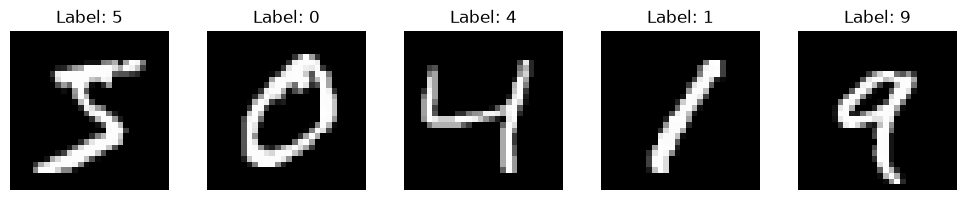

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Trainingsdaten:  {x_train.shape}, Labels: {y_train.shape}")
print(f"Testdaten:       {x_test.shape}, Labels: {y_test.shape}")
print(f"Pixelwerte liegen zwischen {x_train.min()} und {x_train.max()}")
print(f"Vorkommende Klassen: {np.unique(y_train)}")


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Die Labels (0-9) bleiben als einfache Integer erhalten. Wir nutzen dafuer
# spaeter "sparse_categorical_crossentropy", die direkt mit Integer-Labels
# arbeitet (keine manuelle One-Hot-Kodierung noetig).

# Ein paar Beispielbilder zur Kontrolle anzeigen
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("aufgabe5_beispielbilder.png", dpi=150)
plt.show()

**Aufgabe 5.b**

Wir bauen ein Netzwerk, das ähnlich dem Netzwerk aus der Aufgabe 4 ist.

In [3]:
model_simple = Sequential()
model_simple.add(Input(shape=(28, 28)))
model_simple.add(Flatten())
model_simple.add(Dense(10, activation="softmax"))  # Output-Layer

model_simple.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

**Aufgabe 5.c**

Wieder analog zur Aufgabe 4 führen wir die Kompilierung aus, mit der Ausnahme für die Loss-Funktion, diesmal wird 'sparse_categorical_crossentropy' gewählt.


In [4]:
model_simple.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

history_simple = model_simple.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    verbose=1,
)

loss_simple, acc_simple = model_simple.evaluate(x_test, y_test, verbose=0)
print(f"\n[Einfaches Modell] Test-Loss: {loss_simple:.4f}, Test-Genauigkeit: {acc_simple:.2%}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8733 - loss: 0.4855 - val_accuracy: 0.9257 - val_loss: 0.2671
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9120 - loss: 0.3136 - val_accuracy: 0.9333 - val_loss: 0.2413
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9190 - loss: 0.2915 - val_accuracy: 0.9365 - val_loss: 0.2350
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9209 - loss: 0.2804 - val_accuracy: 0.9377 - val_loss: 0.2313
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9234 - loss: 0.2735 - val_accuracy: 0.9387 - val_loss: 0.2300
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9250 - loss: 0.2683 - val_accuracy: 0.9392 - val_loss: 0.2268
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9259 - loss: 0.2642 - val_accuracy: 0.9395 - val_loss: 0.2262
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9267 - loss: 0.2611 - 

**Aufgabe 5.d**
Unten ist gegeben die Confusion Matrix für ein unser neuronales Netzwerk. Aus der Matrix sehen wir, dass manche Ziffern öfter verwechselt werden, zum Beispiel:
2 mit 8 (40 mal) <br>
5 mit 3 (30 mal) <br>
5 mit 8 (29 mal) <br>
9 mit 4 (30 mal) <br>
9 mit 7 (37 mal)



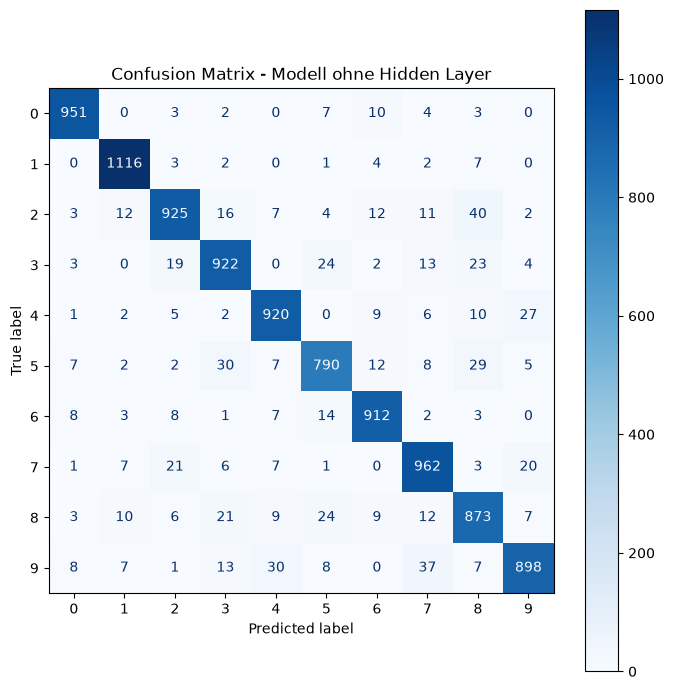

In [5]:
y_pred_simple = np.argmax(model_simple.predict(x_test, verbose=0), axis=1)

cm_simple = confusion_matrix(y_test, y_pred_simple)
disp_simple = ConfusionMatrixDisplay(confusion_matrix=cm_simple)
fig, ax = plt.subplots(figsize=(7, 7))
disp_simple.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix - Modell ohne Hidden Layer")
plt.tight_layout()
plt.savefig("aufgabe5_confusion_simple.png", dpi=150)
plt.show()

**Aufgabe 5.e**
Ald die letzte Teilaufgabe wird das Model mit neuen Hidden-Layers erweitert.

[Hidden Layer,  32 Neuronen] Test-Loss: 0.1103, Test-Genauigkeit: 96.63%
[Hidden Layer,  64 Neuronen] Test-Loss: 0.0878, Test-Genauigkeit: 97.45%
[Hidden Layer, 128 Neuronen] Test-Loss: 0.0770, Test-Genauigkeit: 97.89%

Bestes Modell mit Hidden Layer: 128 Neuronen, Test-Genauigkeit: 97.89%


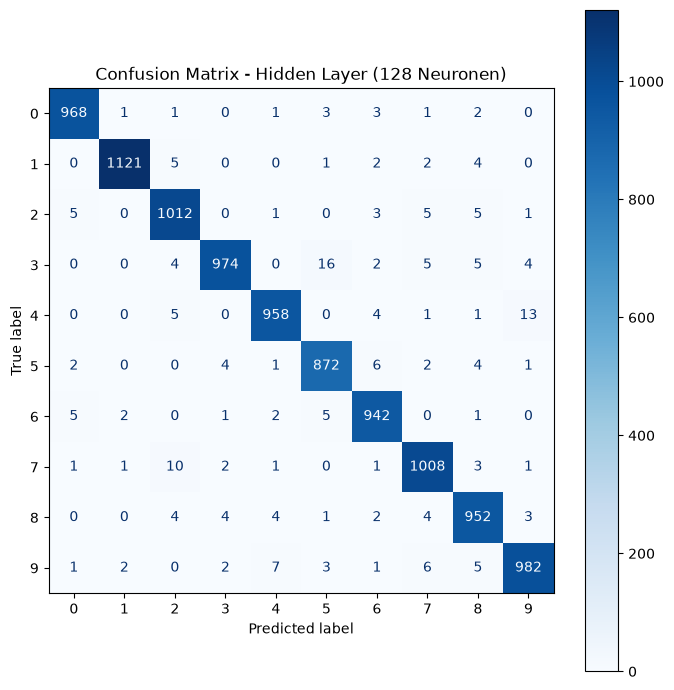


--- Vergleich ---
Ohne Hidden Layer:              92.69%
Mit Hidden Layer ( 32 Neuronen): 96.63%
Mit Hidden Layer ( 64 Neuronen): 97.45%
Mit Hidden Layer (128 Neuronen): 97.89%


In [6]:
hidden_layer_sizes = [32, 64, 128]
results = {}

for n_neurons in hidden_layer_sizes:
    model_hidden = Sequential()
    model_hidden.add(Input(shape=(28, 28)))
    model_hidden.add(Flatten())
    # ReLU ist eine ueblich Wahl fuer Hidden Layer: einfach zu berechnen,
    # vermeidet das Vanishing-Gradient-Problem besser als z.B. Sigmoid.
    model_hidden.add(Dense(n_neurons, activation="relu"))
    model_hidden.add(Dense(10, activation="softmax"))  # Output-Layer

    model_hidden.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"],
    )

    history_hidden = model_hidden.fit(
        x_train, y_train,
        epochs=10,
        validation_split=0.1,
        verbose=0,
    )

    loss_hidden, acc_hidden = model_hidden.evaluate(x_test, y_test, verbose=0)
    results[n_neurons] = (model_hidden, history_hidden, loss_hidden, acc_hidden)
    print(f"[Hidden Layer, {n_neurons:3d} Neuronen] Test-Loss: {loss_hidden:.4f}, "
          f"Test-Genauigkeit: {acc_hidden:.2%}")

# Bestes Modell (hoechste Test-Genauigkeit) fuer die Confusion Matrix waehlen
best_n = max(results, key=lambda n: results[n][3])
best_model, best_history, best_loss, best_acc = results[best_n]
print(f"\nBestes Modell mit Hidden Layer: {best_n} Neuronen, "
      f"Test-Genauigkeit: {best_acc:.2%}")

y_pred_hidden = np.argmax(best_model.predict(x_test, verbose=0), axis=1)
cm_hidden = confusion_matrix(y_test, y_pred_hidden)
disp_hidden = ConfusionMatrixDisplay(confusion_matrix=cm_hidden)
fig, ax = plt.subplots(figsize=(7, 7))
disp_hidden.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title(f"Confusion Matrix - Hidden Layer ({best_n} Neuronen)")
plt.tight_layout()
plt.savefig("aufgabe5_confusion_hidden.png", dpi=150)
plt.show()

# Vergleich der Test-Genauigkeit: ohne vs. mit Hidden Layer
print("\n--- Vergleich ---")
print(f"Ohne Hidden Layer:              {acc_simple:.2%}")
for n_neurons, (_, _, _, acc) in results.items():
    print(f"Mit Hidden Layer ({n_neurons:3d} Neuronen): {acc:.2%}")